In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

In [ ]:
import pandas as pd

# =========================
# 1. LOAD DATA
# =========================

# Load customers data
customers = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Datathon 2026/Data/customers.csv"
)
print("Customers DataFrame shape:", customers_df.shape)
print("Customers DataFrame head:")
display(customers_df.head())

# Load orders data
orders = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Datathon 2026/Data/orders.csv"
)

order_items = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Datathon 2026/Data/order_items.csv"
)


Customers DataFrame shape: (121930, 7)
Customers DataFrame head:


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


/tmp/ipykernel_905/172879571.py:20: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(


In [ ]:
order_items["revenue"] = order_items["quantity"] * order_items["unit_price"]

In [ ]:
order_revenue = order_items.groupby("order_id")["revenue"].sum().reset_index()
orders = orders.merge(order_revenue, on="order_id", how="left")

In [ ]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

df = orders.groupby("customer_id").agg({
    "order_id": "nunique",
    "revenue": "sum",
    "order_date": ["max", "min"]
}).reset_index()

In [ ]:
df.columns = ["customer_id", "total_orders", "total_revenue", "last_order", "first_order"]

In [ ]:
df.shape

(90246, 5)

In [ ]:
today = orders["order_date"].max()

df["days_since_last_order"] = (today - df["last_order"]).dt.days

In [ ]:
rfm = df[[
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]].copy()

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.describe())

            Recency     Frequency      Monetary
count  90246.000000  90246.000000  9.024600e+04
mean    1254.412240      7.168683  1.820632e+05
std     1028.215961      8.629654  2.287514e+05
min        0.000000      1.000000  5.486700e+02
25%      298.000000      2.000000  3.292234e+04
50%      991.000000      4.000000  9.394407e+04
75%     1994.000000      9.000000  2.443168e+05
max     3832.000000    107.000000  3.618914e+06


In [ ]:
rfm.head()

,Recency,Frequency,Monetary
0,616,6,142803.47
1,178,4,225225.94
2,3442,3,52093.47
3,916,1,13340.32
4,1375,5,69075.34


In [ ]:
# =========================
# 3. HANDLE SKEWNESS
# =========================

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])


In [ ]:
# =========================
# 4. STANDARDIZE DATA
# =========================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
pip install kneed

Optimal K: 5


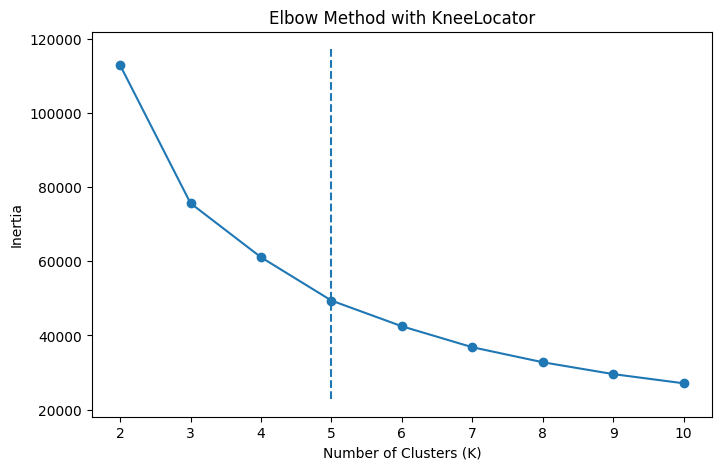

In [ ]:
# =========================
# 5. FIND OPTIMAL K (KNEE LOCATOR)
# =========================

from kneed import KneeLocator

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# =========================
# FIND ELBOW / KNEE POINT
# =========================

knee_locator = KneeLocator(
    K_range,
    inertia,
    curve='convex',
    direction='decreasing'
)

optimal_k = knee_locator.elbow

print("Optimal K:", optimal_k)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

# Highlight optimal K

plt.vlines(
    optimal_k,
    plt.ylim()[0],
    plt.ylim()[1],
    linestyles='dashed'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method with KneeLocator")

plt.show()

In [ ]:
# =========================
# 6. TRAIN FINAL MODEL
# =========================
# Ví dụ chọn K = 4
# (Sau khi xem elbow)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

df["Cluster"] = clusters

In [ ]:
# =========================
# 7. SILHOUETTE SCORE
# =========================

score = silhouette_score(rfm_scaled, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3499


In [ ]:

# =========================
# 8. CLUSTER SUMMARY
# =========================

cluster_summary = df.groupby("Cluster")[[
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]].mean().round(2)

cluster_summary["customer_count"] = (
    df.groupby("Cluster")["customer_id"]
    .count()
)

print(cluster_summary)


         days_since_last_order  total_orders  total_revenue  customer_count
Cluster                                                                    
0                      1972.39          3.03       79886.22           17146
1                       851.89          1.74       33847.12           13432
2                       344.13         20.42      530031.44           19120
3                      2826.31          1.18       18832.15           16222
4                       637.85          6.67      171274.22           24326


In [ ]:
cluster_names = {
    0: "At Risk Customers",
    1: "Low Value Customers",
    2: "VIP Customers",
    3: "Dormant Customers",
    4: "Active Customers"
}
df["Cluster_Name"] = df["Cluster"].map(cluster_names)

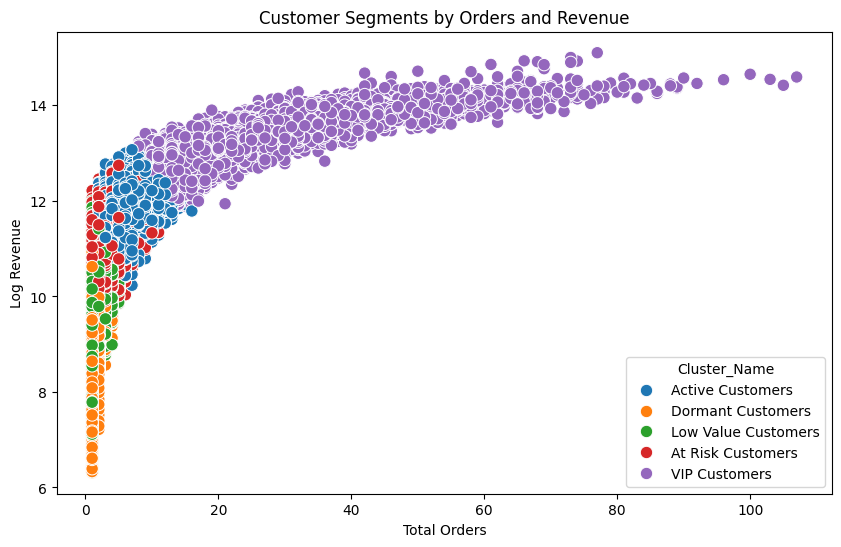

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="total_orders",
    y=np.log1p(df["total_revenue"]),
    hue="Cluster_Name",
    s=80
)

plt.title("Customer Segments by Orders and Revenue")

plt.xlabel("Total Orders")
plt.ylabel("Log Revenue")

plt.show()

In [ ]:
df.head()

,customer_id,total_orders,total_revenue,last_order,first_order,days_since_last_order,Cluster,Cluster_Name
0,1,6,142803.47,2021-04-24,2012-07-25,616,4,Active Customers
1,2,4,225225.94,2022-07-06,2013-09-20,178,4,Active Customers
2,3,3,52093.47,2013-07-29,2012-08-27,3442,3,Dormant Customers
3,4,1,13340.32,2020-06-28,2020-06-28,916,1,Low Value Customers
4,5,5,69075.34,2019-03-27,2012-08-09,1375,0,At Risk Customers


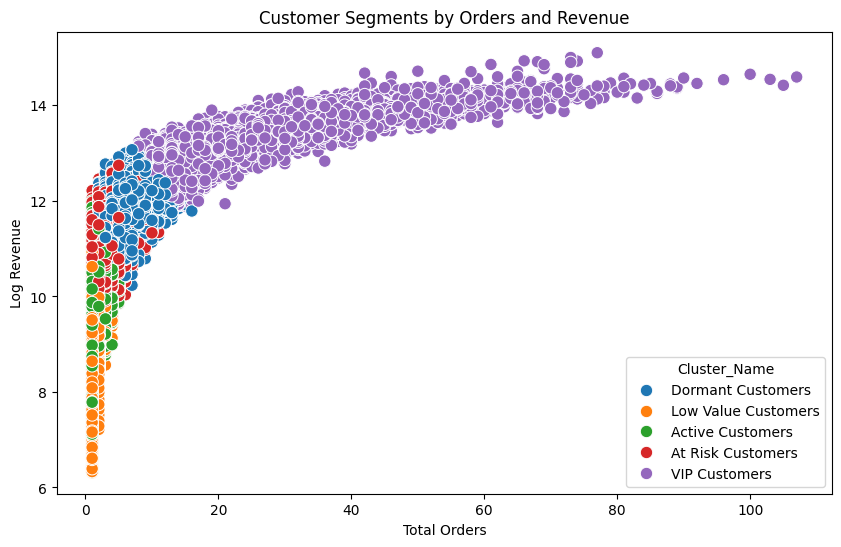

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="total_orders",
    y=np.log1p(df["total_revenue"]),
    hue="Cluster_Name",
    s=80
)

plt.title("Customer Segments by Orders and Revenue")

plt.xlabel("Total Orders")
plt.ylabel("Log Revenue")

plt.show()